<a href="https://colab.research.google.com/github/vishnugajavada/Alzheimer-Quantum-Graph-Sage/blob/main/Alzheimer_SkullStrip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELL 1 — Install Dependencies
!pip uninstall -y torch torchvision torchaudio torch-geometric torch-scatter torch-sparse 2>/dev/null
!pip install -q torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 \
    --index-url https://download.pytorch.org/whl/cu121
!pip install -q torch-geometric
!pip install -q torch-scatter torch-sparse \
    -f https://data.pyg.org/whl/torch-2.3.0+cu121.html
!pip install -q pennylane scikit-learn seaborn opencv-python-headless
print(' Done! → Runtime → Restart session → Run from Cell 2')

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 67.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 47.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 52.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 56.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 69.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 724.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━

In [ ]:
# CELL 2 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print(' Drive mounted!')

Mounted at /content/drive
 Drive mounted!


In [ ]:
# CELL 3 — Imports
import os, warnings
os.environ['NUMPY_EXPERIMENTAL_ARRAY_FUNCTION'] = '0'
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pennylane as qml
from pennylane import numpy as pnp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, log_loss,
    precision_recall_fscore_support, brier_score_loss
)
from sklearn.calibration import calibration_curve
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import SAGEConv, GATConv, global_mean_pool, global_max_pool

torch.manual_seed(42); np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
COLORS = ['#4C72B0', '#DD8452']
print(f'   Device  : {device}')
print(f'   PyTorch : {torch.__version__}')
print(f'   PennyLane: {qml.__version__}')

   Device  : cuda
   PyTorch : 2.3.0+cu121
   PennyLane: 0.44.1


Loading dataset...

  NonDemented          (label=0): 800 images
  MildDemented         (label=1): 800 images
  ModerateDemented     (label=2): 64 images
  VeryMildDemented     (label=3): 800 images

Total: 2464 | NonDemented: 800 | AD: 800
Node features: torch.Size([64, 8]) | Edges: 420


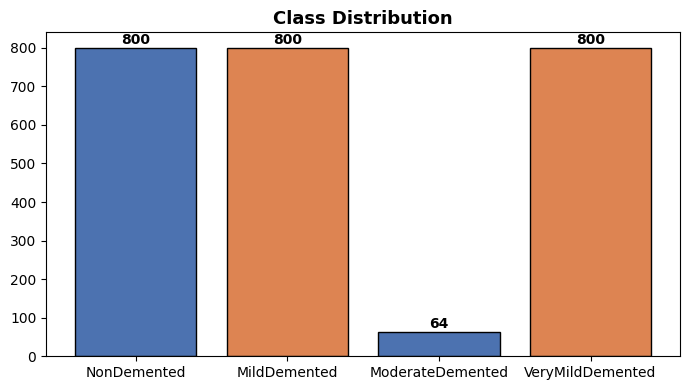

 Dataset ready!


In [ ]:
# CELL 4 — Dataset Loading & Graph Construction
LABELS_MAP  = {
    'NonDemented'     : 0,
    'MildDemented'    : 1,
    'ModerateDemented': 2,
    'VeryMildDemented': 3
}
CLASS_NAMES   = ['NonDemented', 'MildDemented', 'ModerateDemented', 'VeryMildDemented']
DATA_ROOT     = '/content/drive/MyDrive/Efficient1/Alzheimer_s Dataset'
IMAGE_GRID    = (8, 8)
IMAGE_SIZE    = (128, 128)
MAX_PER_CLASS = 800

def skull_strip(img_uint8):
    """
    Skull stripping: Otsu threshold + morphological ops + largest component.
    Input : uint8 grayscale image
    Output: skull-stripped uint8 grayscale image
    """
    blurred = cv2.GaussianBlur(img_uint8, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255,
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        brain_mask = (labels == largest).astype(np.uint8) * 255
    else:
        brain_mask = closed
    kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    brain_mask = cv2.dilate(brain_mask, kernel2, iterations=2)
    return cv2.bitwise_and(img_uint8, img_uint8, mask=brain_mask)

def preprocess_image(image_path, size=IMAGE_SIZE, augment=False):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img = cv2.resize(img, size)
    img = skull_strip(img)                      # skull stripping
    img = img.astype(np.float32) / 255.0
    if augment:
        img = np.rot90(img, k=np.random.choice([0,1,2,3]))
        if np.random.rand() > 0.5: img = np.fliplr(img)
        img = np.clip(img + np.random.normal(0, 0.01, img.shape), 0, 1)
    return img

def image_to_graph(img, grid=IMAGE_GRID):
    rows, cols = grid
    h, w = img.shape
    rh, rw = h // rows, w // cols
    node_features = []
    for r in range(rows):
        for c in range(cols):
            region = img[r*rh:(r+1)*rh, c*rw:(c+1)*rw]
            node_features.append([
                float(np.mean(region)),
                float(np.std(region)),
                float(np.max(region)),
                float(np.min(region)),
                float(np.median(region)),
                float(np.var(region)),
                float(np.sum(np.abs(np.diff(region))) / max(region.size, 1)),
                float(np.mean(np.abs(region - np.mean(region))))
            ])
    x = torch.tensor(node_features, dtype=torch.float)
    num_nodes = rows * cols
    edge_indices = []
    for i in range(num_nodes):
        r1, c1 = i // cols, i % cols
        for j in range(i+1, num_nodes):
            r2, c2 = j // cols, j % cols
            if abs(r1-r2) <= 1 and abs(c1-c2) <= 1:
                edge_indices += [[i,j],[j,i]]
    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    return Data(x=x, edge_index=edge_index)

print('Loading dataset...\n')
dataset = []; class_counts = {0:0, 1:0, 2:0, 3:0}
# Store raw images for visualization
sample_images = {0: [], 1: [], 2: [], 3: []}

for folder_name, label in LABELS_MAP.items():
    folder_path = os.path.join(DATA_ROOT, folder_name)
    if not os.path.exists(folder_path):
        print(f' Not found: {folder_path}'); continue
    files = [f for f in os.listdir(folder_path)
             if f.lower().endswith(('.jpg','.png','.jpeg'))][:MAX_PER_CLASS]
    loaded = 0
    for filename in files:
        file_path = os.path.join(folder_path, filename)
        img = preprocess_image(file_path, augment=(np.random.rand()>0.5))
        if img is None: continue
        g = image_to_graph(img)
        g.y = torch.tensor([label], dtype=torch.long)
        g.img = torch.tensor(img, dtype=torch.float32)  # store for visualization
        dataset.append(g)
        if len(sample_images[label]) < 5:
            sample_images[label].append(img)
        loaded += 1
    class_counts[label] += loaded
    print(f'  {folder_name:20s} (label={label}): {loaded} images')

print(f'\nTotal: {len(dataset)} | NonDemented: {class_counts[0]} | AD: {class_counts[1]}')
print(f'Node features: {dataset[0].x.shape} | Edges: {dataset[0].edge_index.shape[1]}')

plt.figure(figsize=(7,4))
bars = plt.bar(CLASS_NAMES, [class_counts[i] for i in range(4)], color=COLORS, edgecolor='black')
for bar,c in zip(bars,[class_counts[i] for i in range(4)]):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
             str(c), ha='center', fontweight='bold')
plt.title('Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('class_dist.png', dpi=120); plt.show()
print(' Dataset ready!')


In [ ]:
# CELL 5 — Train / Val / Test Split & DataLoaders
labels_list = [d.y.item() for d in dataset]
train_val, test_data = train_test_split(
    dataset, test_size=0.15, random_state=42, stratify=labels_list)
tv_labels = [d.y.item() for d in train_val]
train_data, val_data = train_test_split(
    train_val, test_size=0.176, random_state=42, stratify=tv_labels)

print(f'Train:{len(train_data)} | Val:{len(val_data)} | Test:{len(test_data)}')
BATCH = 32
train_loader = GeoDataLoader(train_data, batch_size=BATCH, shuffle=True)
val_loader   = GeoDataLoader(val_data,   batch_size=BATCH, shuffle=False)
test_loader  = GeoDataLoader(test_data,  batch_size=BATCH, shuffle=False)

y_tr = np.array([d.y.item() for d in train_data])
cw   = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weights = torch.tensor(cw, dtype=torch.float32).to(device)
for n,w in zip(CLASS_NAMES, cw): print(f'  {n}: {w:.4f}')
print(' DataLoaders ready!')

Train:1725 | Val:369 | Test:370
  NonDemented: 0.7701
  MildDemented: 0.7701
  ModerateDemented: 9.5833
  VeryMildDemented: 0.7701
 DataLoaders ready!


In [ ]:
# CELL 6 — Quantum Feature Extractor
N_QUBITS = 8
N_LAYERS = 4

dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev, interface='torch')
def circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {'weights': (N_LAYERS, N_QUBITS, 3)}

class QuantumFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(circuit, weight_shapes)
    def forward(self, x):
        x = torch.tanh(x) * np.pi
        return self.qlayer(x)

print(f' Quantum Feature Extractor ready')
print(f'   {N_QUBITS} qubits | {N_LAYERS} layers | AngleEmbedding + StronglyEntangling')

 Quantum Feature Extractor ready
   8 qubits | 4 layers | AngleEmbedding + StronglyEntangling


In [ ]:
# CELL 7 — SAGEConv  Model
HIDDEN = 128
OUT    = 4

class QuantumGraphSAGE(nn.Module):
    """
    Hybrid Quantum-GNN:
    QFE (PennyLane 8-qubit) → Linear → GATConv(4-head) → SAGEConv×2
    → Mean+Max pooling → MLP classifier
    """
    def __init__(self, in_channels=8, hidden_channels=128,
                 out_channels=2, n_qubits=8, n_layers=4):
        super().__init__()
        self.qfe        = QuantumFeatureExtractor()
        self.input_proj = nn.Linear(n_qubits, hidden_channels)
        self.conv1      = GATConv(hidden_channels, hidden_channels//2, heads=4, concat=True)
        self.bn1        = nn.BatchNorm1d(hidden_channels * 2)
        self.conv2      = SAGEConv(hidden_channels * 2, hidden_channels)
        self.bn2        = nn.BatchNorm1d(hidden_channels)
        self.conv3      = SAGEConv(hidden_channels, hidden_channels)
        self.bn3        = nn.BatchNorm1d(hidden_channels)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_channels // 2, out_channels)
        )

    def forward(self, data):
        x, ei, b = data.x, data.edge_index, data.batch
        x = self.qfe(x)
        x = F.relu(self.input_proj(x))
        x = F.elu(self.bn1(self.conv1(x, ei)))
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, ei)))
        x = F.relu(self.bn3(self.conv3(x, ei)))
        x = torch.cat([global_mean_pool(x,b), global_max_pool(x,b)], dim=1)
        return self.classifier(x)

    def get_node_embeddings(self, data):
        """Returns node-level embeddings for explainability."""
        x, ei = data.x, data.edge_index
        x = self.qfe(x)
        x = F.relu(self.input_proj(x))
        x = F.elu(self.bn1(self.conv1(x, ei)))
        x = F.relu(self.bn2(self.conv2(x, ei)))
        x = F.relu(self.bn3(self.conv3(x, ei)))
        return x

model  = QuantumGraphSAGE(in_channels=N_QUBITS, hidden_channels=HIDDEN,
                           out_channels=OUT, n_qubits=N_QUBITS, n_layers=N_LAYERS).to(device)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f' Model ready — trainable params: {params:,}')
print(f'   QFE → GATConv(4-head) → SAGEConv×2 → MLP')

 Model ready — trainable params: 176,036
   QFE → GATConv(4-head) → SAGEConv×2 → MLP


In [ ]:
# CELL 8 — Optimizer, Loss, Scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
print(' Setup ready!')
print('   Optimizer : Adam lr=5e-4, wd=1e-4')
print('   Scheduler : ReduceLROnPlateau factor=0.5, patience=5')
print('   Loss      : CrossEntropyLoss + class weights')

 Setup ready!
   Optimizer : Adam lr=5e-4, wd=1e-4
   Scheduler : ReduceLROnPlateau factor=0.5, patience=5
   Loss      : CrossEntropyLoss + class weights


In [ ]:
# CELL 9 — Training Loop
EPOCHS = 100
best_val_acc = 0.0; best_state = None; best_epoch = 0

history = {k:[] for k in ['epoch','lr',
    'train_loss','val_loss',
    'train_acc','val_acc',
    'train_f1','val_f1',
    'train_auc','val_auc',
    'train_prec','val_prec',
    'train_rec','val_rec']}

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss=0; preds=[]; labels=[]; probs=[]
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            batch = batch.to(device)
            out   = model(batch)
            loss  = criterion(out, batch.y)
            if training:
                optimizer.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
            prob = F.softmax(out, dim=1)[:,1].detach().cpu().numpy()
            probs.extend(prob)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(batch.y.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(labels, preds)
    f1   = f1_score(labels, preds, average='weighted')
    prec = precision_score(labels, preds, average='weighted', zero_division=0)
    rec  = recall_score(labels, preds, average='weighted', zero_division=0)
    try:   auc_s = roc_auc_score(labels, probs)
    except: auc_s = 0.0
    return avg_loss, acc, f1, prec, rec, auc_s

print('  Training started...\n')
print(f'{"Ep":>4} | {"TrLoss":>7} {"TrAcc":>7} {"TrAUC":>7} | '
      f'{"VaLoss":>7} {"VaAcc":>7} {"VaAUC":>7} | {"Best":>6}')
print('-'*82)

for epoch in range(1, EPOCHS+1):
    tl,ta,tf,tp,tr,ta_auc = run_epoch(train_loader, True)
    vl,va,vf,vp,vr,va_auc = run_epoch(val_loader,   False)
    scheduler.step(vl)

    if va > best_val_acc:
        best_val_acc=va; best_epoch=epoch
        best_state={k:v.clone() for k,v in model.state_dict().items()}

    history['epoch'].append(epoch)
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta);  history['val_acc'].append(va)
    history['train_f1'].append(tf);   history['val_f1'].append(vf)
    history['train_auc'].append(ta_auc); history['val_auc'].append(va_auc)
    history['train_prec'].append(tp); history['val_prec'].append(vp)
    history['train_rec'].append(tr);  history['val_rec'].append(vr)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    if epoch%10==0:
        print(f'{epoch:>4} | {tl:>7.4f} {ta:>7.4f} {ta_auc:>7.4f} | '
              f'{vl:>7.4f} {va:>7.4f} {va_auc:>7.4f} | {best_val_acc:.4f} ')

model.load_state_dict(best_state)
print(f'\n Done! Best Val Acc: {best_val_acc:.4f} ({best_val_acc*100:.2f}%) @ epoch {best_epoch}')

  Training started...

  Ep |  TrLoss   TrAcc   TrAUC |  VaLoss   VaAcc   VaAUC |   Best
----------------------------------------------------------------------------------
  10 |  0.8929  0.6209  0.0000 |  0.7668  0.6341  0.0000 | 0.6477 
  20 |  0.6186  0.7119  0.0000 |  0.6496  0.6667  0.0000 | 0.7100 
  30 |  0.4052  0.8012  0.0000 |  0.4828  0.7724  0.0000 | 0.7724 
  40 |  0.3240  0.8586  0.0000 |  0.4258  0.8130  0.0000 | 0.8130 
  50 |  0.1559  0.9328  0.0000 |  0.4979  0.8103  0.0000 | 0.8266 
  60 |  0.0810  0.9623  0.0000 |  0.4763  0.8293  0.0000 | 0.8401 
  70 |  0.0625  0.9751  0.0000 |  0.5087  0.8401  0.0000 | 0.8537 
  80 |  0.0766  0.9670  0.0000 |  0.5134  0.8482  0.0000 | 0.8618 
  90 |  0.0671  0.9733  0.0000 |  0.5133  0.8347  0.0000 | 0.8618 
 100 |  0.0545  0.9826  0.0000 |  0.5045  0.8591  0.0000 | 0.8618 

 Done! Best Val Acc: 0.8618 (86.18%) @ epoch 75


In [ ]:
# CELL 10 — Full Test Evaluation (run once, used by all viz cells)
model.eval()
test_preds, test_labels, test_probs_full = [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out   = model(batch)
        prob  = F.softmax(out, dim=1).cpu().numpy()
        test_probs_full.extend(prob)
        test_preds.extend(out.argmax(1).cpu().numpy())
        test_labels.extend(batch.y.cpu().numpy())

test_probs_full = np.array(test_probs_full)
test_preds      = np.array(test_preds)
test_labels     = np.array(test_labels)

from sklearn.preprocessing import label_binarize
test_labels_bin = label_binarize(test_labels, classes=list(range(4)))

acc   = accuracy_score(test_labels, test_preds)
f1    = f1_score(test_labels, test_preds, average='weighted')
prec  = precision_score(test_labels, test_preds, average='weighted', zero_division=0)
rec   = recall_score(test_labels, test_preds, average='weighted', zero_division=0)
mcc   = matthews_corrcoef(test_labels, test_preds)
kappa = cohen_kappa_score(test_labels, test_preds)
ll    = log_loss(test_labels, test_probs_full)
auc_s = roc_auc_score(test_labels_bin, test_probs_full,
                       multi_class='ovr', average='weighted')
ap    = average_precision_score(test_labels_bin, test_probs_full, average='weighted')
p_pc, r_pc, f_pc, s_pc = precision_recall_fscore_support(
    test_labels, test_preds, labels=list(range(4)), zero_division=0)
cm   = confusion_matrix(test_labels, test_preds)
cm_n = cm.astype('float') / cm.sum(axis=1)[:,np.newaxis]

print('   Test evaluation complete!')
print(f'   Accuracy : {acc*100:.2f}%')
print(f'   F1 Score : {f1*100:.2f}%')
print(f'   ROC-AUC  : {auc_s:.4f}')
print(f'   MCC      : {mcc:.4f}')


   Test evaluation complete!
   Accuracy : 85.95%
   F1 Score : 86.01%
   ROC-AUC  : 0.9637
   MCC      : 0.7947


In [ ]:
# CELL 12 — Classification Report (Text)
print('='*65)
print('   FULL TEST SET RESULTS — Quantum GNN (4-Class Classification)')
print('='*65)
print(f'  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Weighted F1       : {f1:.4f}')
print(f'  Weighted Precision: {prec:.4f}')
print(f'  Weighted Recall   : {rec:.4f}')
print(f'  ROC-AUC           : {auc_s:.4f}')
print(f'  Average Precision : {ap:.4f}')
print(f'  MCC               : {mcc:.4f}')
print(f'  Cohen Kappa       : {kappa:.4f}')
print(f'  Log Loss          : {ll:.4f}')
print('='*65)
print()
print(classification_report(test_labels, test_preds,
                             target_names=CLASS_NAMES, digits=4))

   FULL TEST SET RESULTS — Quantum GNN (4-Class Classification)
  Accuracy          : 0.8595  (85.95%)
  Weighted F1       : 0.8601
  Weighted Precision: 0.8613
  Weighted Recall   : 0.8595
  ROC-AUC           : 0.9637
  Average Precision : 0.9346
  MCC               : 0.7947
  Cohen Kappa       : 0.7944
  Log Loss          : 0.4649

                  precision    recall  f1-score   support

     NonDemented     0.8240    0.8583    0.8408       120
    MildDemented     0.9565    0.9167    0.9362       120
ModerateDemented     0.8000    0.8000    0.8000        10
VeryMildDemented     0.8083    0.8083    0.8083       120

        accuracy                         0.8595       370
       macro avg     0.8472    0.8458    0.8463       370
    weighted avg     0.8613    0.8595    0.8601       370



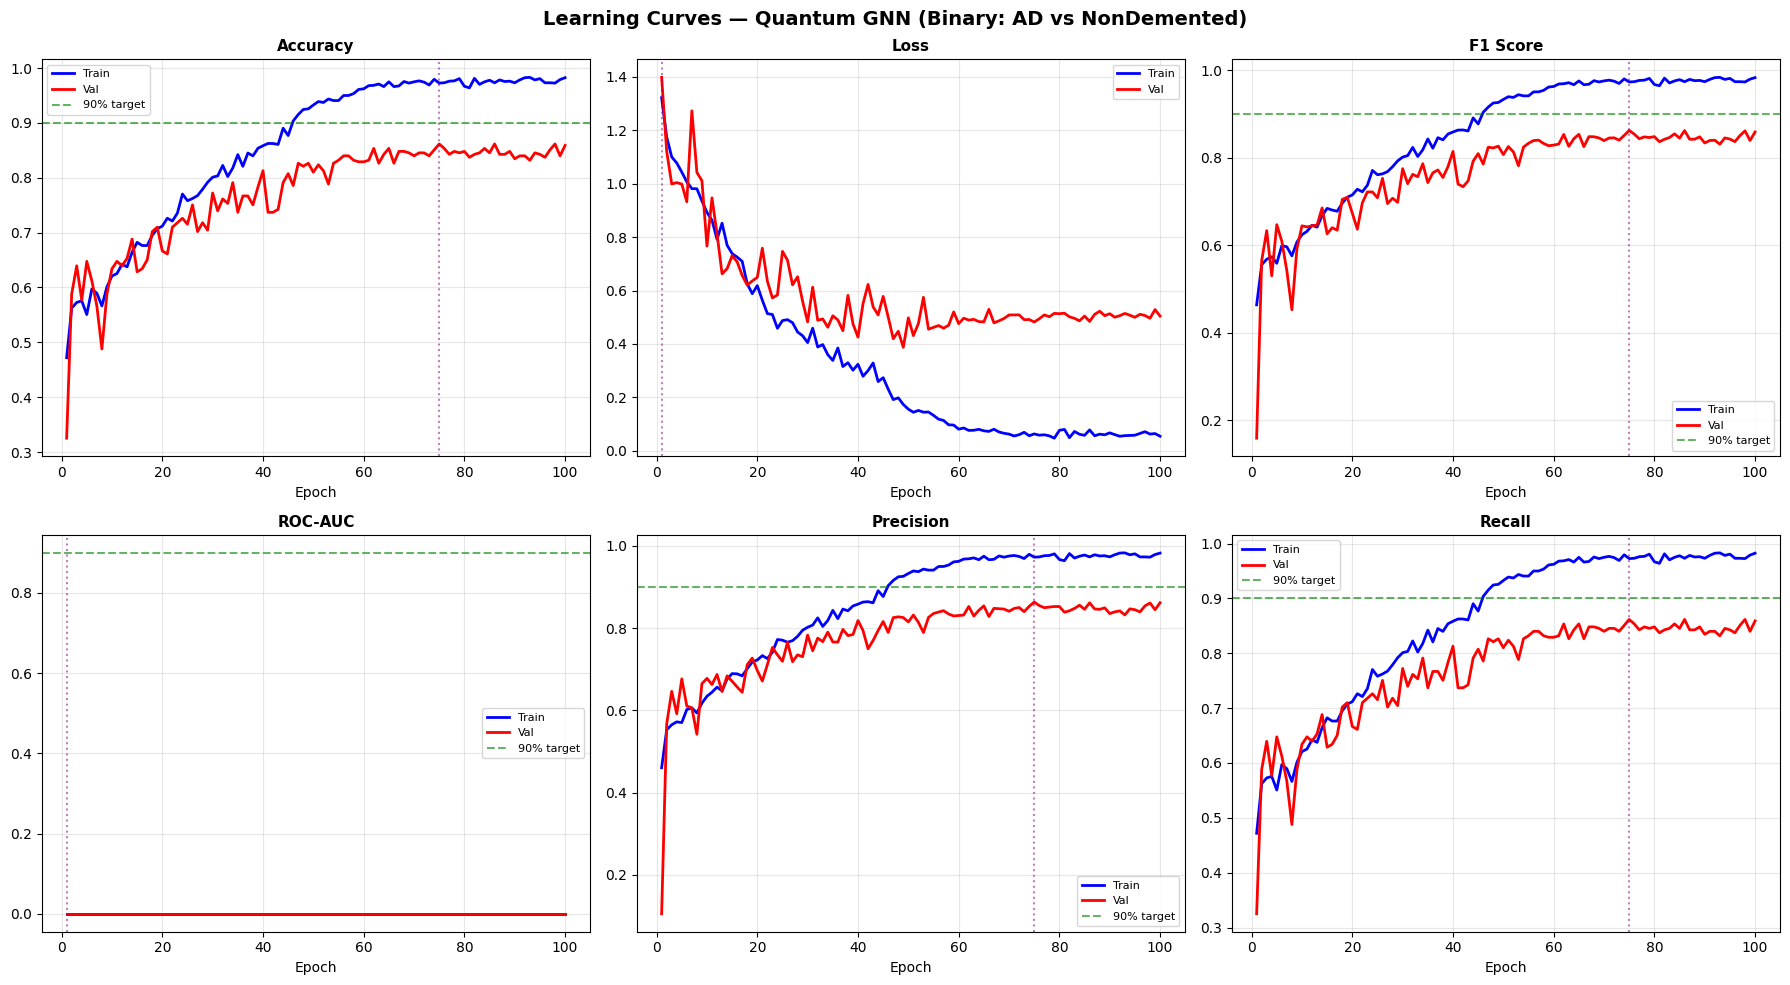

  Saved: learning_curves.png


In [ ]:
# CELL 13 — Learning Curves
ep = history['epoch']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Learning Curves — Quantum GNN (Binary: AD vs NonDemented)',
             fontsize=14, fontweight='bold')

curve_cfg = [
    ('train_acc',  'val_acc',  'Accuracy',  True),
    ('train_loss', 'val_loss', 'Loss',       False),
    ('train_f1',   'val_f1',   'F1 Score',  True),
    ('train_auc',  'val_auc',  'ROC-AUC',   True),
    ('train_prec', 'val_prec', 'Precision', True),
    ('train_rec',  'val_rec',  'Recall',    True),
]
for ax, (tk, vk, title, show_90) in zip(axes.flatten(), curve_cfg):
    ax.plot(ep, history[tk], 'b-', lw=2, label='Train')
    ax.plot(ep, history[vk], 'r-', lw=2, label='Val')
    if show_90:
        ax.axhline(0.90, color='green', ls='--', alpha=0.6, label='90% target')
    best_v = max(history[vk])
    best_e = history['epoch'][history[vk].index(best_v)]
    ax.axvline(best_e, color='purple', ls=':', alpha=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('  Saved: learning_curves.png')

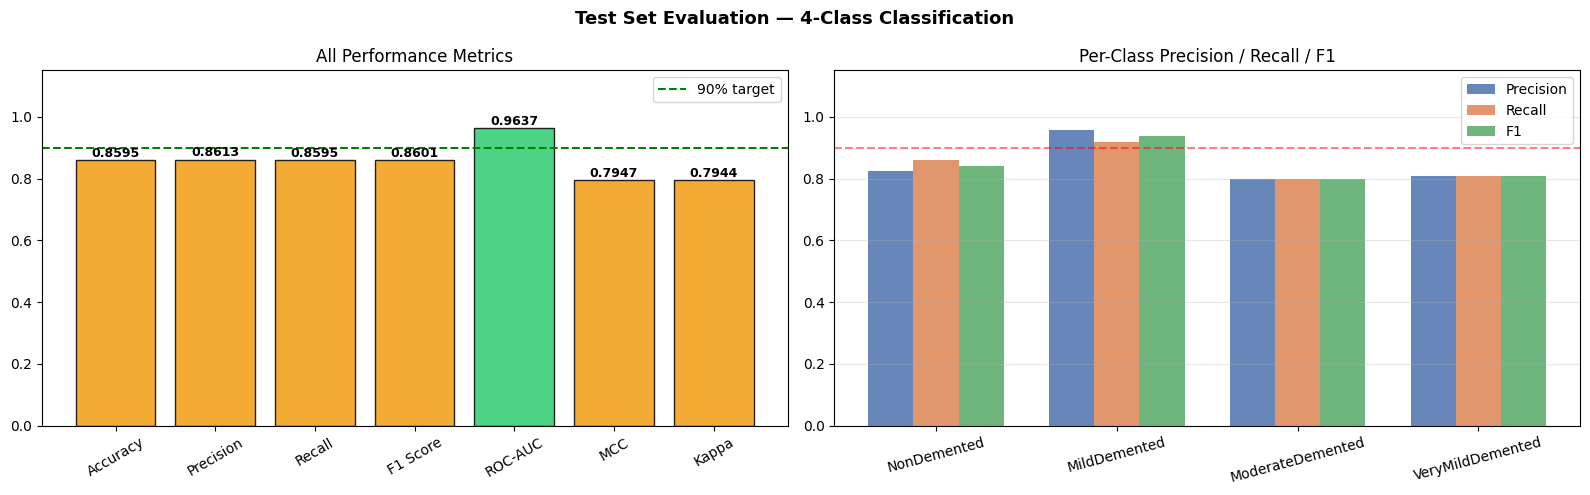

 Saved: test_evaluation.png


In [ ]:
# CELL 14 — Test Set Evaluation & Classification Report (Visual)
metrics = {
    'Accuracy': acc, 'Precision': prec, 'Recall': rec,
    'F1 Score': f1,  'ROC-AUC': auc_s, 'MCC': mcc,
    'Kappa': kappa
}
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Test Set Evaluation — 4-Class Classification',
             fontsize=13, fontweight='bold')

# Bar chart of metrics
names = list(metrics.keys()); vals = list(metrics.values())
bar_colors = ['#2ecc71' if v >= 0.90 else '#e74c3c' if v < 0.70 else '#f39c12' for v in vals]
bars = axes[0].bar(names, vals, color=bar_colors, alpha=0.85, edgecolor='black')
axes[0].axhline(0.90, color='green', ls='--', lw=1.5, label='90% target')
axes[0].set_ylim(0, 1.15); axes[0].set_title('All Performance Metrics')
axes[0].tick_params(axis='x', rotation=30); axes[0].legend()
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.01,
                 f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

# Per-class metrics (4 classes)
x = np.arange(4); w = 0.25
axes[1].bar(x-w, p_pc, w, label='Precision', color='#4C72B0', alpha=0.85)
axes[1].bar(x,   r_pc, w, label='Recall',    color='#DD8452', alpha=0.85)
axes[1].bar(x+w, f_pc, w, label='F1',        color='#55A868', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASS_NAMES, rotation=15)
axes[1].set_ylim(0, 1.15); axes[1].legend()
axes[1].axhline(0.90, color='red', ls='--', alpha=0.5)
axes[1].set_title('Per-Class Precision / Recall / F1')
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('test_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Saved: test_evaluation.png')

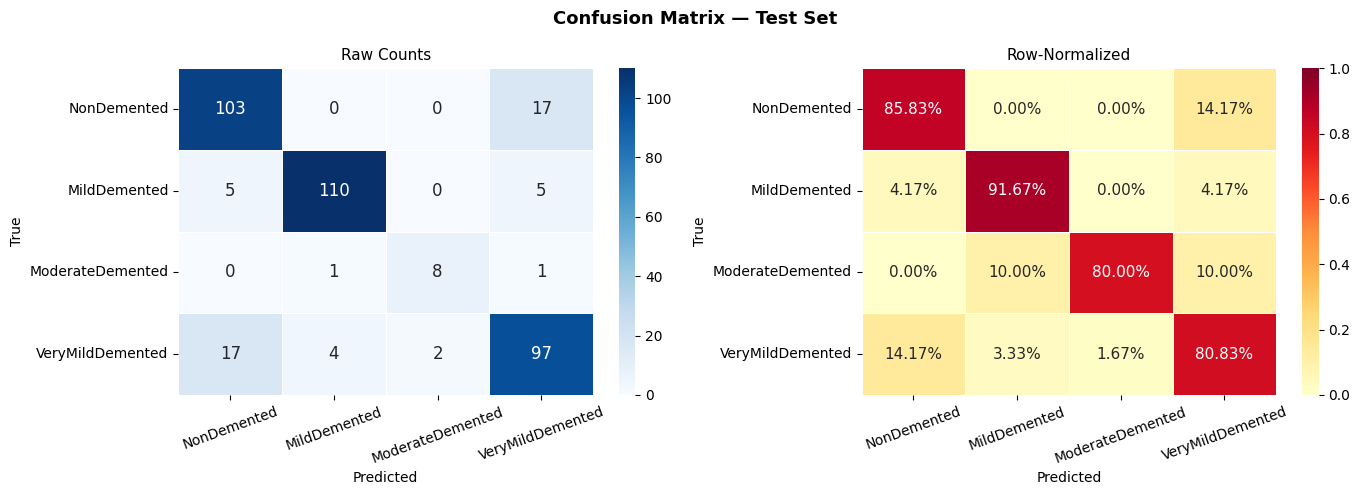

 Saved: confusion_matrix.png


In [ ]:
# CELL 15 — Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5, annot_kws={'size':12})
axes[0].set_title('Raw Counts', fontsize=11)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=20)

sns.heatmap(cm_n, annot=True, fmt='.2%', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1, annot_kws={'size':11})
axes[1].set_title('Row-Normalized', fontsize=11)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Saved: confusion_matrix.png')

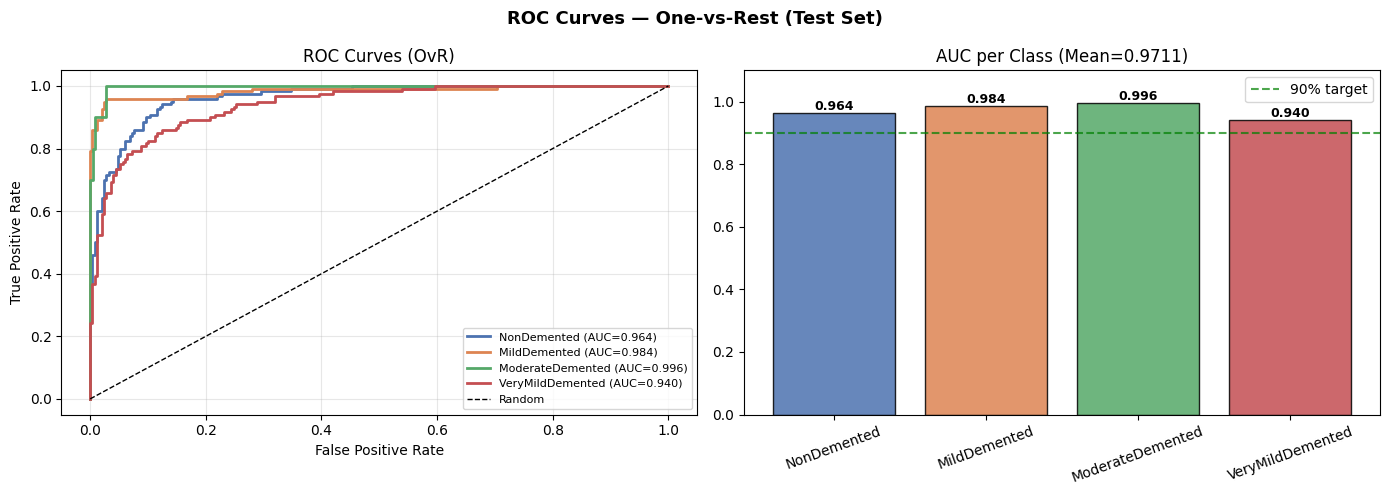

Per-class AUC: ['0.9636', '0.9845', '0.9958', '0.9404']
Weighted AUC : 0.9637
Saved: roc_curves.png


In [ ]:
# CELL 16 — ROC Curves (One-vs-Rest for 4 Classes)
COLORS4 = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ROC Curves — One-vs-Rest (Test Set)', fontsize=13, fontweight='bold')

all_aucs = []
for i, (cn, col) in enumerate(zip(CLASS_NAMES, COLORS4)):
    fpr_i, tpr_i, _ = roc_curve(test_labels_bin[:, i], test_probs_full[:, i])
    auc_i = auc(fpr_i, tpr_i)
    all_aucs.append(auc_i)
    axes[0].plot(fpr_i, tpr_i, color=col, lw=2, label=f'{cn} (AUC={auc_i:.3f})')

axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves (OvR)'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

bars = axes[1].bar(CLASS_NAMES, all_aucs, color=COLORS4, alpha=0.85, edgecolor='black')
axes[1].axhline(0.90, color='green', ls='--', alpha=0.7, label='90% target')
axes[1].set_ylim(0, 1.1); axes[1].set_title(f'AUC per Class (Mean={np.mean(all_aucs):.4f})')
axes[1].legend()
for bar, v in zip(bars, all_aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}',
                 ha='center', fontweight='bold', fontsize=9)
axes[1].tick_params(axis='x', rotation=20)

fpr_micro, tpr_micro, _ = roc_curve(test_labels_bin.ravel(), test_probs_full.ravel())
roc_auc_val = auc(fpr_micro, tpr_micro)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Per-class AUC: {[f"{a:.4f}" for a in all_aucs]}')
print(f'Weighted AUC : {auc_s:.4f}')
print('Saved: roc_curves.png')

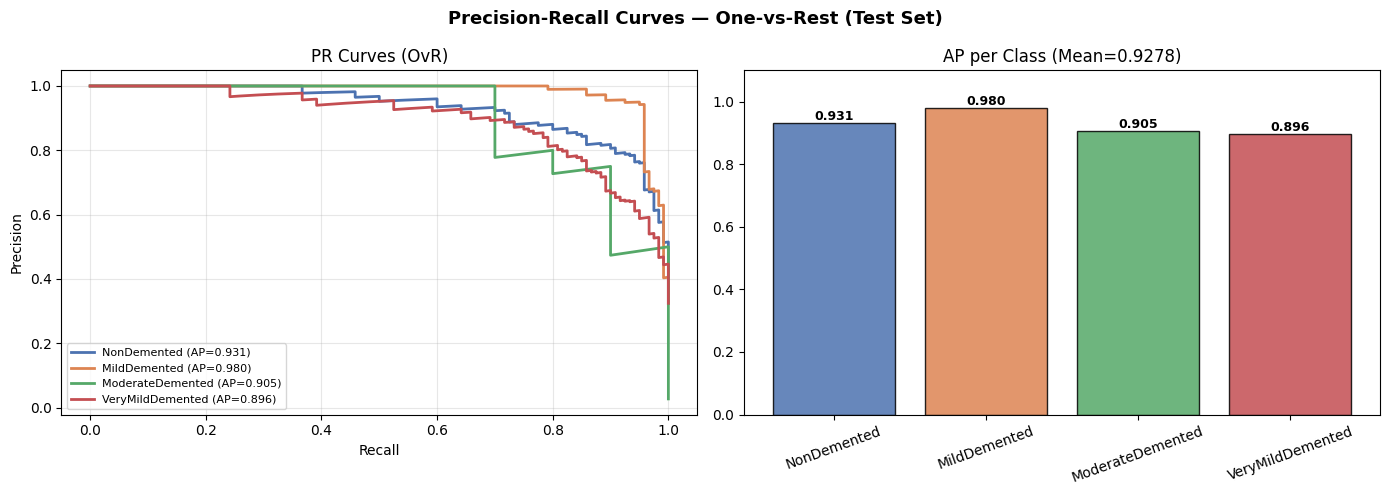

Mean AP: 0.9278
 Saved: pr_curves.png


In [ ]:
# CELL 17 — Precision-Recall Curves (4 Classes)
COLORS4 = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Precision-Recall Curves — One-vs-Rest (Test Set)', fontsize=13, fontweight='bold')

all_aps = []
for i, (cn, col) in enumerate(zip(CLASS_NAMES, COLORS4)):
    p_i, r_i, _ = precision_recall_curve(test_labels_bin[:, i], test_probs_full[:, i])
    ap_i = average_precision_score(test_labels_bin[:, i], test_probs_full[:, i])
    all_aps.append(ap_i)
    axes[0].plot(r_i, p_i, color=col, lw=2, label=f'{cn} (AP={ap_i:.3f})')

axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('PR Curves (OvR)'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

bars = axes[1].bar(CLASS_NAMES, all_aps, color=COLORS4, alpha=0.85, edgecolor='black')
axes[1].set_ylim(0, 1.1); axes[1].set_title(f'AP per Class (Mean={np.mean(all_aps):.4f})')
for bar, v in zip(bars, all_aps):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}',
                 ha='center', fontweight='bold', fontsize=9)
axes[1].tick_params(axis='x', rotation=20)

ap = np.mean(all_aps)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Mean AP: {ap:.4f}')
print(' Saved: pr_curves.png')

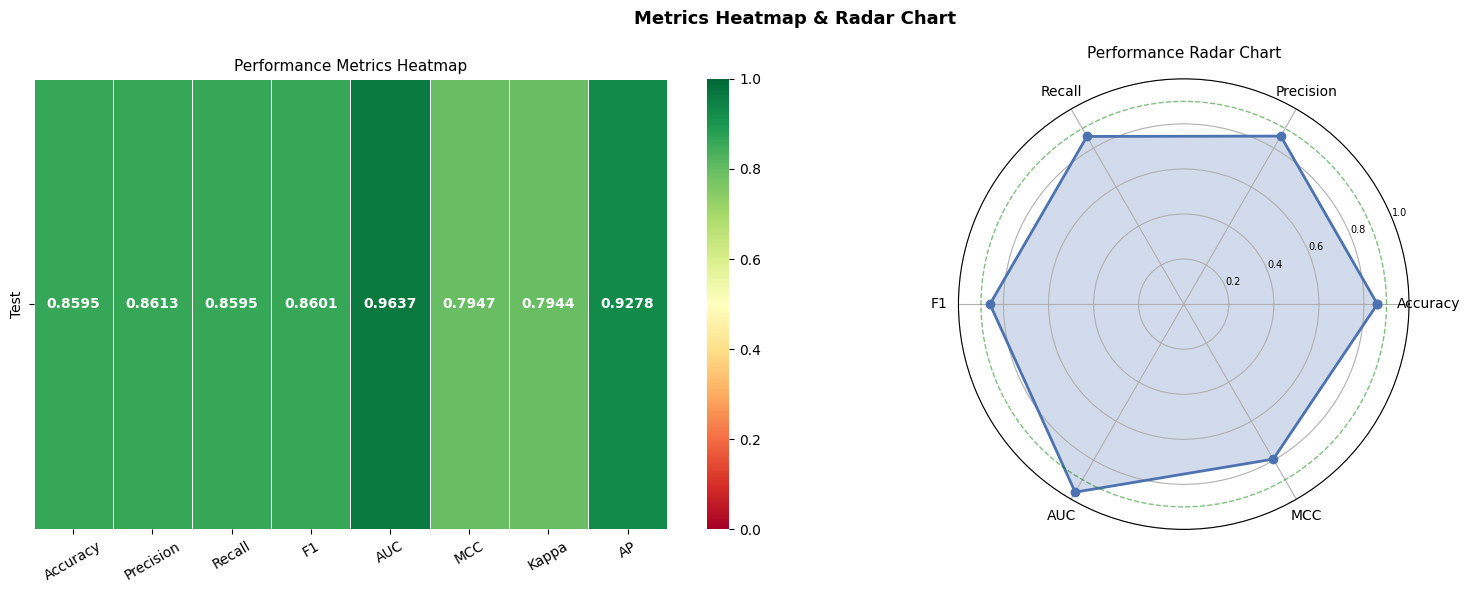

 Saved: metrics_heatmap_radar.png


In [ ]:
# CELL 18 — Metrics Heatmap & Radar Chart
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 6))
fig.suptitle('Metrics Heatmap & Radar Chart', fontsize=13, fontweight='bold')
gs  = gridspec.GridSpec(1, 2, figure=fig)

# --- Heatmap ---
ax1 = fig.add_subplot(gs[0])
metric_names  = ['Accuracy','Precision','Recall','F1','AUC','MCC','Kappa','AP']
metric_values = [acc, prec, rec, f1, auc_s, mcc, kappa, ap]
heat_data = np.array(metric_values).reshape(1,-1)
sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='RdYlGn',
            xticklabels=metric_names, yticklabels=['Test'],
            ax=ax1, vmin=0, vmax=1, linewidths=0.5,
            annot_kws={'size':10, 'weight':'bold'})
ax1.set_title('Performance Metrics Heatmap', fontsize=11)
ax1.tick_params(axis='x', rotation=30)

# --- Radar Chart ---
ax2 = fig.add_subplot(gs[1], projection='polar')
radar_metrics = ['Accuracy','Precision','Recall','F1','AUC','MCC']
radar_values  = [acc, prec, rec, f1, auc_s, max(mcc, 0)]
N = len(radar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
radar_values_plot = radar_values + radar_values[:1]
ax2.plot(angles, radar_values_plot, 'o-', lw=2, color='#4C72B0')
ax2.fill(angles, radar_values_plot, alpha=0.25, color='#4C72B0')
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(radar_metrics, fontsize=10)
ax2.set_ylim(0, 1)
ax2.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax2.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7)
ax2.axhline(y=0.9, color='green', ls='--', alpha=0.5, lw=1)
ax2.set_title('Performance Radar Chart', fontsize=11, pad=15)

plt.tight_layout()
plt.savefig('metrics_heatmap_radar.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Saved: metrics_heatmap_radar.png')

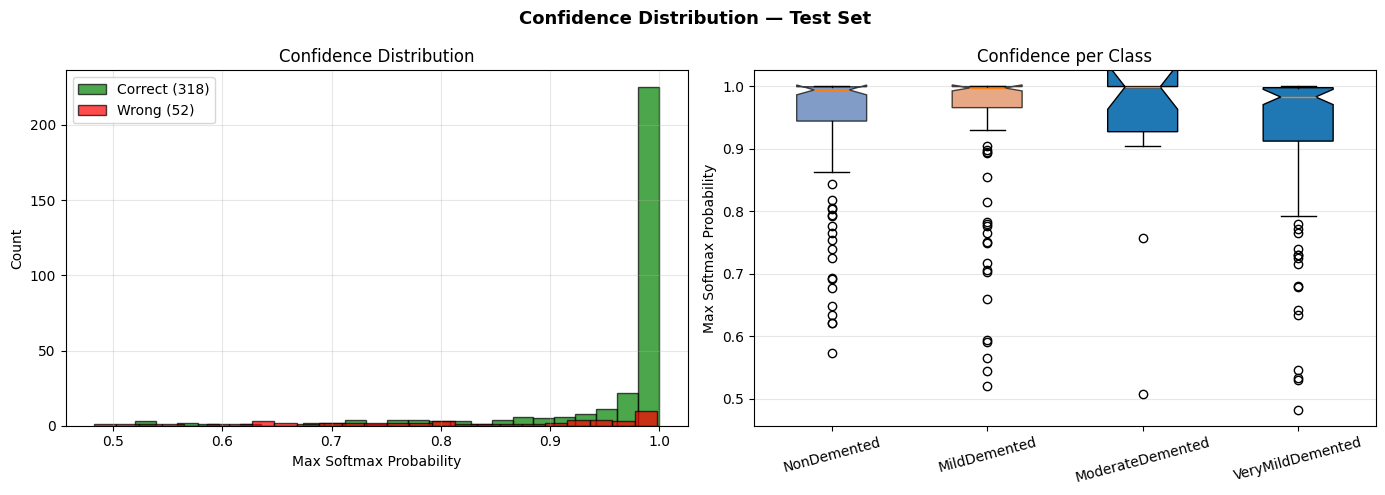

Mean confidence (correct) : 0.9574
Mean confidence (wrong)   : 0.8175
 Saved: confidence_distribution.png


In [ ]:
# CELL 19 — Confidence Distribution
correct   = test_preds == test_labels
max_probs = test_probs_full.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confidence Distribution — Test Set', fontsize=13, fontweight='bold')

axes[0].hist(max_probs[correct].tolist(),  bins=25, alpha=0.7,
             color='green', label=f'Correct ({correct.sum()})', edgecolor='black')
axes[0].hist(max_probs[~correct].tolist(), bins=25, alpha=0.7,
             color='red',   label=f'Wrong ({(~correct).sum()})', edgecolor='black')
axes[0].set_title('Confidence Distribution')
axes[0].set_xlabel('Max Softmax Probability')
axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

box_data = [max_probs[test_labels==i].tolist() for i in range(4)]
bp = axes[1].boxplot(box_data, labels=CLASS_NAMES, patch_artist=True, notch=True)
for patch, col in zip(bp['boxes'], COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[1].set_title('Confidence per Class')
axes[1].set_ylabel('Max Softmax Probability')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Mean confidence (correct) : {max_probs[correct].mean():.4f}')
print(f'Mean confidence (wrong)   : {max_probs[~correct].mean():.4f}')
print(' Saved: confidence_distribution.png')


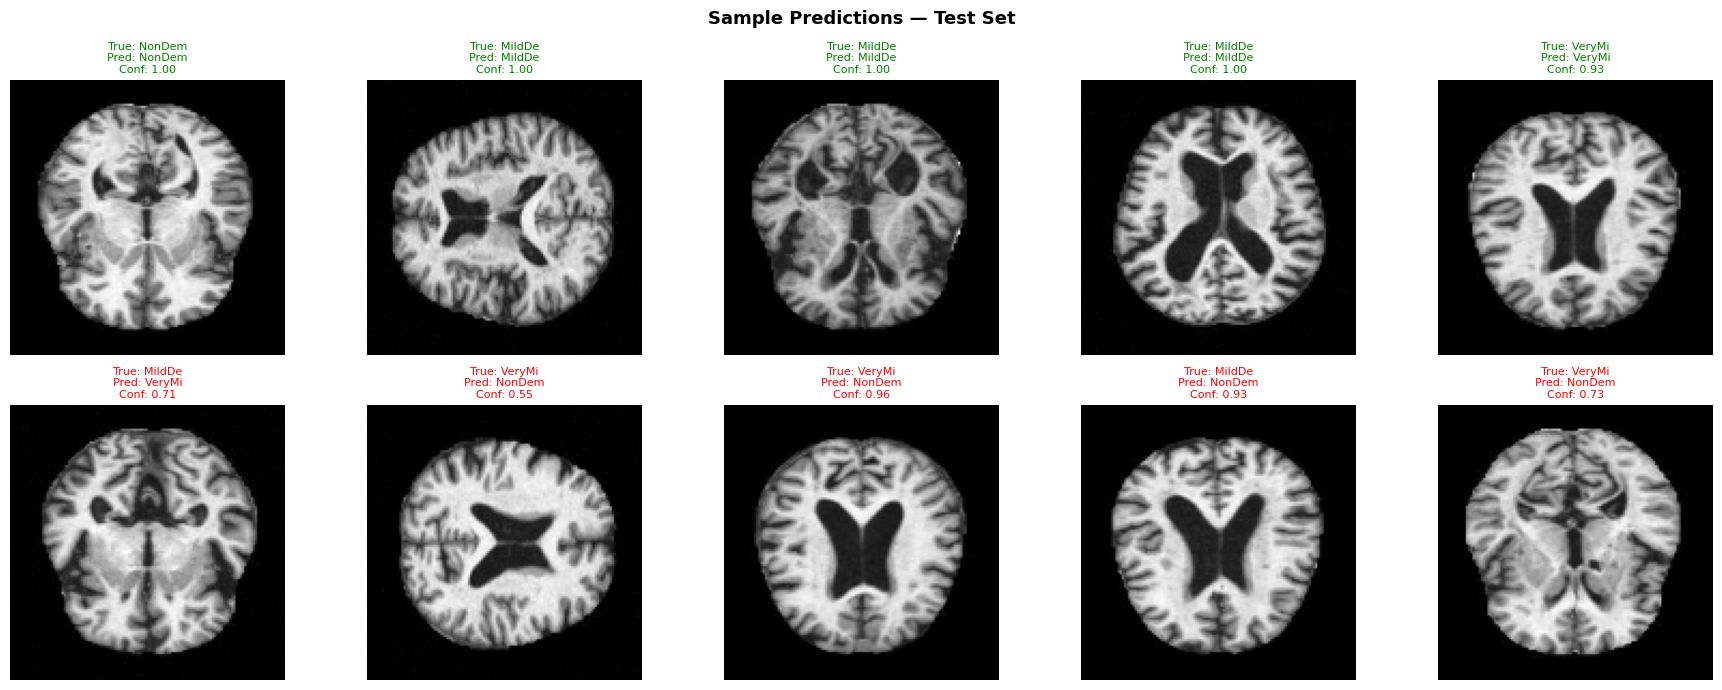

 Saved: sample_predictions.png


In [ ]:
# CELL 20 — Sample Predictions Visualization
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Sample Predictions — Test Set', fontsize=13, fontweight='bold')

correct_samples = []
wrong_samples   = []

model.eval()
with torch.no_grad():
    for g in test_data:
        if not hasattr(g, 'img'): continue
        out  = model(g.to(device))
        prob = F.softmax(out, dim=1).cpu().numpy()[0]
        pred = int(out.argmax(1).cpu().item())
        true = int(g.y.item())
        img  = g.img.cpu().numpy()
        entry = (img, true, pred, prob)
        if pred == true and len(correct_samples) < 5:
            correct_samples.append(entry)
        elif pred != true and len(wrong_samples) < 5:
            wrong_samples.append(entry)
        if len(correct_samples) == 5 and len(wrong_samples) == 5:
            break

for col, (img, true, pred, prob) in enumerate(correct_samples[:5]):
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(
        f'True: {CLASS_NAMES[true][:6]}\nPred: {CLASS_NAMES[pred][:6]}\nConf: {prob[pred]:.2f}',
        color='green', fontsize=8)
    axes[0, col].axis('off')

for col, (img, true, pred, prob) in enumerate(wrong_samples[:5]):
    axes[1, col].imshow(img, cmap='gray')
    axes[1, col].set_title(
        f'True: {CLASS_NAMES[true][:6]}\nPred: {CLASS_NAMES[pred][:6]}\nConf: {prob[pred]:.2f}',
        color='red', fontsize=8)
    axes[1, col].axis('off')

axes[0,0].set_ylabel(' Correct', fontsize=11, color='green', labelpad=10)
axes[1,0].set_ylabel(' Wrong', fontsize=11, color='red', labelpad=10)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Saved: sample_predictions.png')

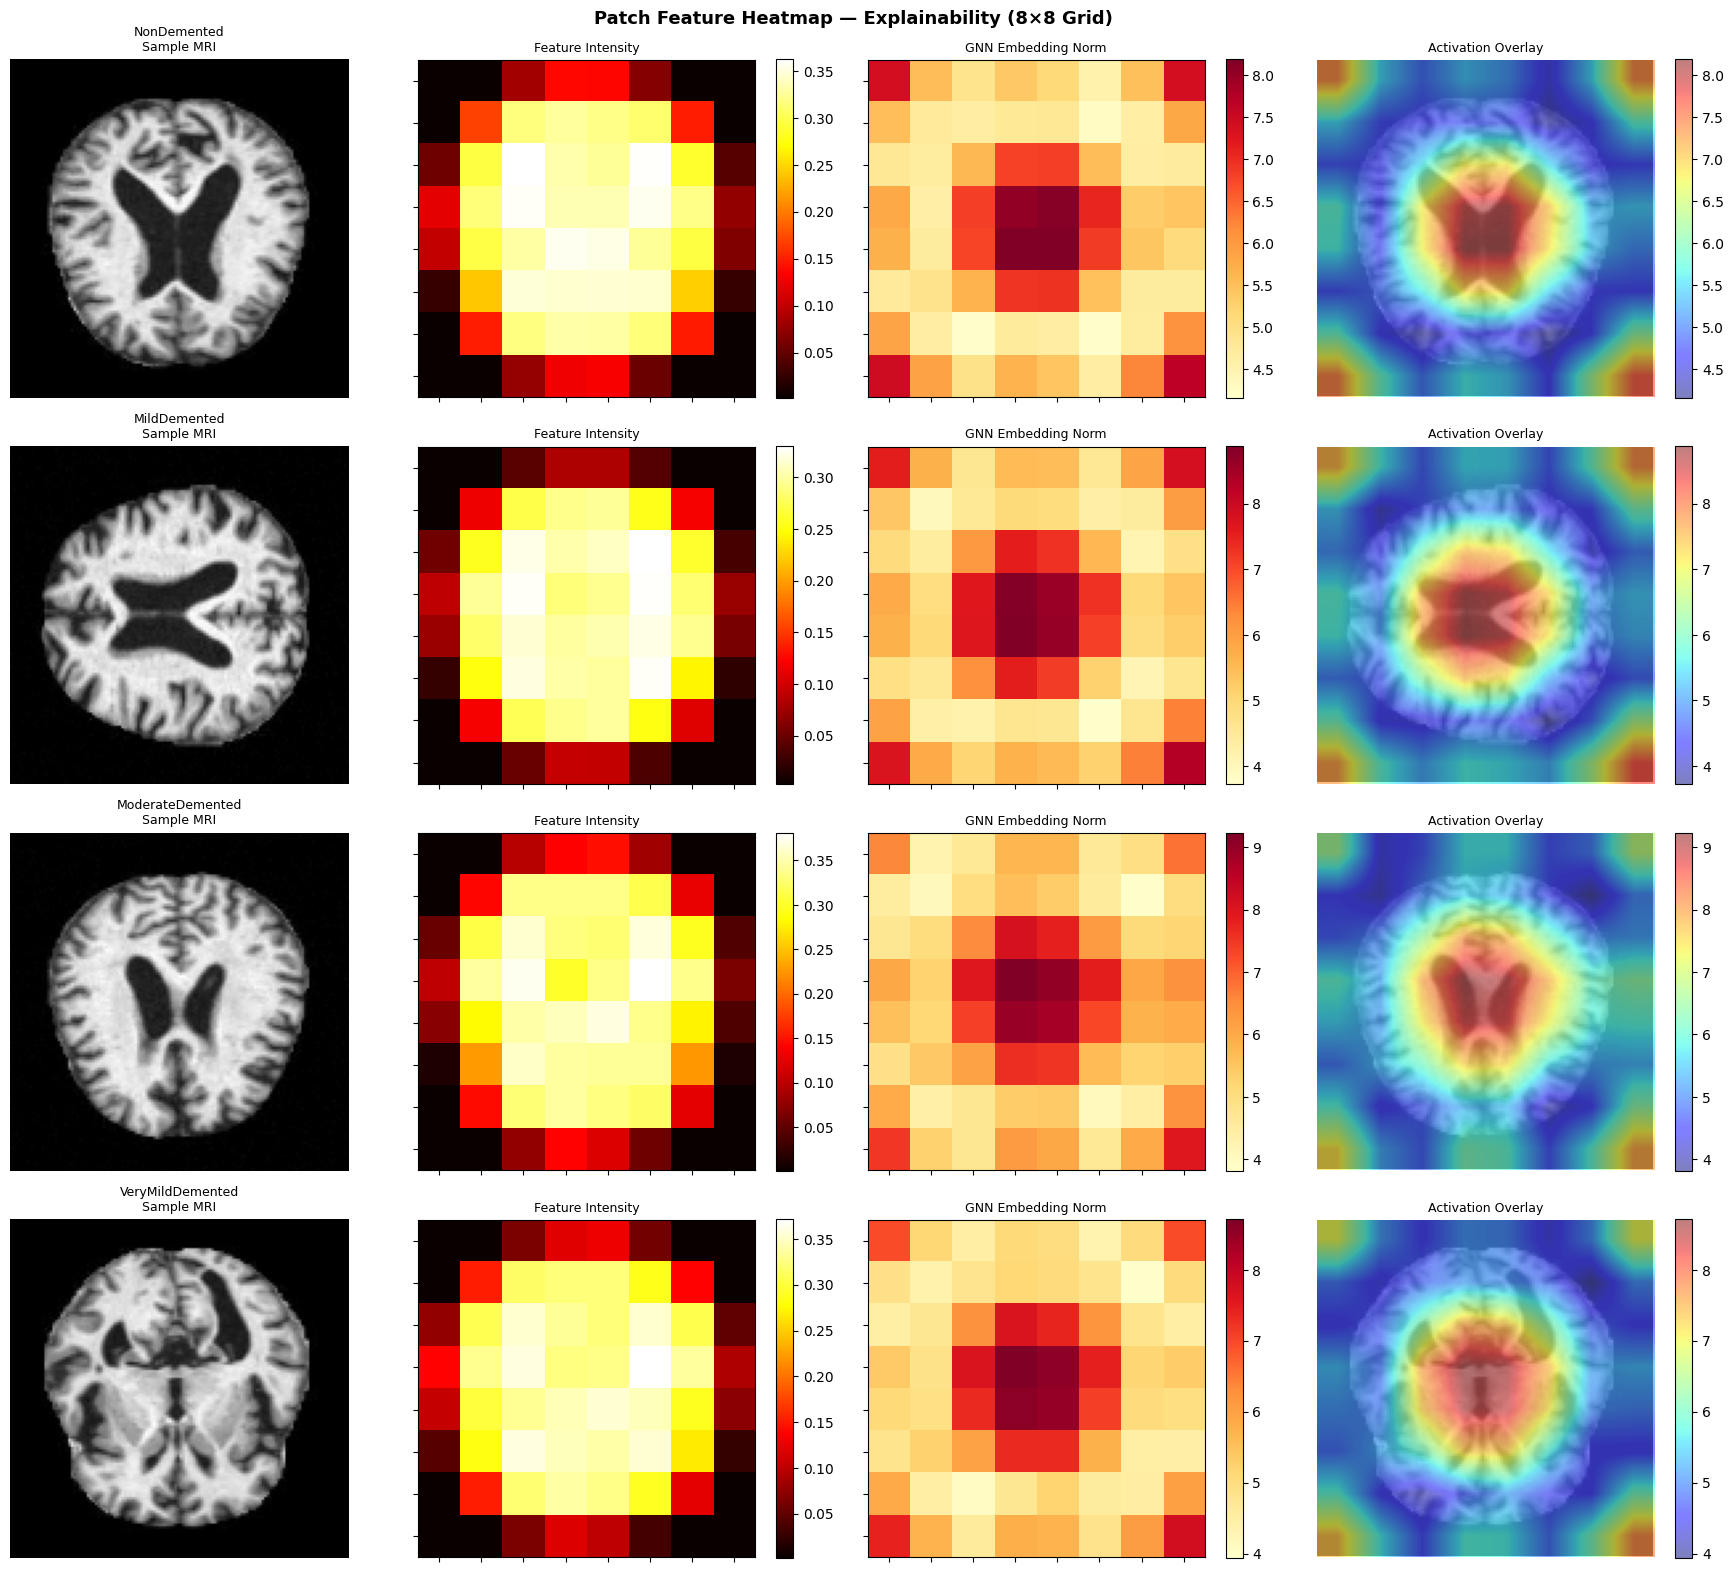

 Saved: patch_heatmap.png


In [ ]:
# CELL 21 — Patch Feature Heatmap (Explainability)
COLORS4 = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
fig.suptitle('Patch Feature Heatmap — Explainability (8×8 Grid)',
             fontsize=13, fontweight='bold')

model.eval()
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_samples = [g for g in test_data if g.y.item() == cls_idx
                   and hasattr(g, 'img')][:8]
    if not cls_samples:
        for c in range(4):
            axes[cls_idx, c].axis('off')
        continue

    all_node_feats = []
    all_node_embs  = []
    for g in cls_samples:
        all_node_feats.append(g.x.cpu().numpy())
        with torch.no_grad():
            emb = model.get_node_embeddings(g.to(device))
            all_node_embs.append(emb.cpu().numpy())

    avg_feat       = np.mean(all_node_feats, axis=0)
    avg_emb        = np.mean(all_node_embs,  axis=0)
    feat_intensity = avg_feat.mean(axis=1).reshape(8, 8)
    emb_intensity  = np.linalg.norm(avg_emb, axis=1).reshape(8, 8)

    # Col 0 — sample MRI
    if sample_images[cls_idx]:
        axes[cls_idx, 0].imshow(sample_images[cls_idx][0], cmap='gray')
    axes[cls_idx, 0].set_title(f'{cls_name}\nSample MRI', fontsize=9)
    axes[cls_idx, 0].axis('off')

    # Col 1 — feature intensity
    im1 = axes[cls_idx, 1].imshow(feat_intensity, cmap='hot', interpolation='nearest')
    axes[cls_idx, 1].set_title('Feature Intensity', fontsize=9)
    plt.colorbar(im1, ax=axes[cls_idx, 1])

    # Col 2 — GNN embedding norm
    im2 = axes[cls_idx, 2].imshow(emb_intensity, cmap='YlOrRd', interpolation='nearest')
    axes[cls_idx, 2].set_title('GNN Embedding Norm', fontsize=9)
    plt.colorbar(im2, ax=axes[cls_idx, 2])

    # Col 3 — activation overlay
    if sample_images[cls_idx]:
        axes[cls_idx, 3].imshow(sample_images[cls_idx][0], cmap='gray', alpha=0.6)
        overlay = axes[cls_idx, 3].imshow(
            emb_intensity, cmap='jet', alpha=0.5,
            extent=[0, 128, 128, 0], interpolation='bilinear'
        )
        plt.colorbar(overlay, ax=axes[cls_idx, 3])
    axes[cls_idx, 3].set_title('Activation Overlay', fontsize=9)
    axes[cls_idx, 3].axis('off')

for ax in axes.flatten():
    ax.tick_params(labelbottom=False, labelleft=False)

plt.tight_layout()
plt.savefig('patch_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Saved: patch_heatmap.png')

Final accuracy gap : 12.35%
 Overfitting (> 10%)


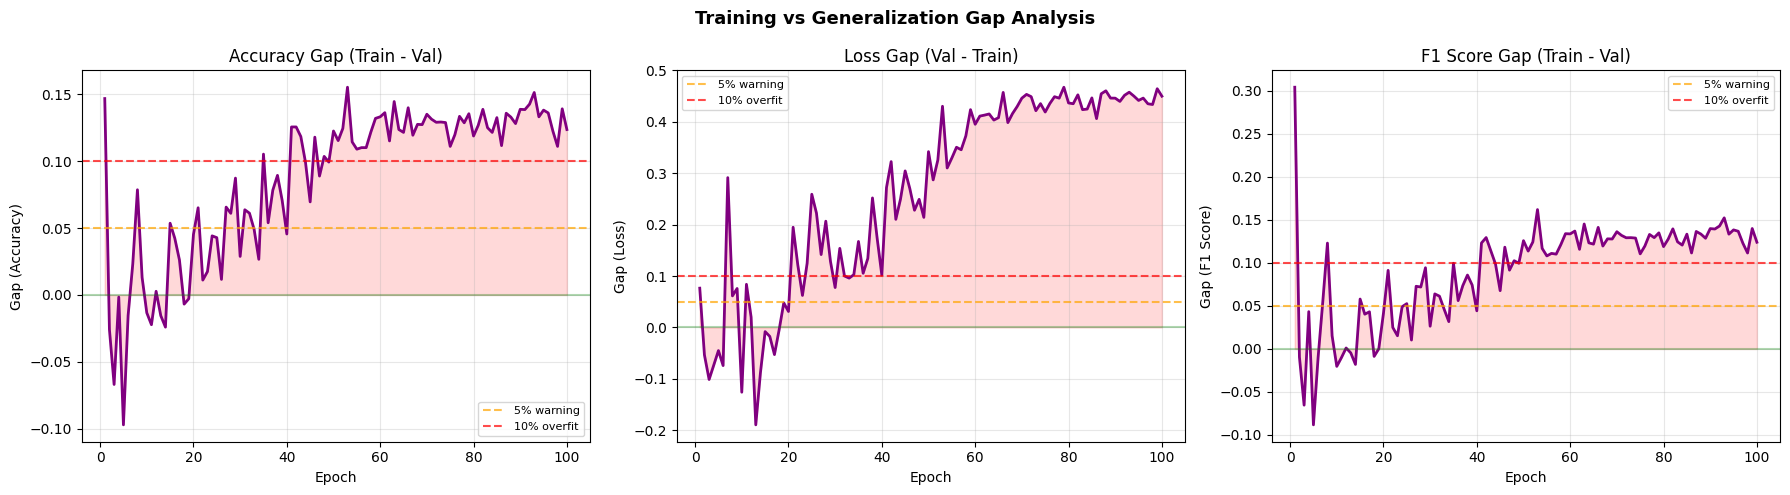

 Saved: generalization_gap.png


In [ ]:
# CELL 22 — Training vs Generalization Gap Plot
ep = history['epoch']
acc_gap  = [tr-va for tr,va in zip(history['train_acc'],  history['val_acc'])]
loss_gap = [va-tr for tr,va in zip(history['train_loss'], history['val_loss'])]
f1_gap   = [tr-va for tr,va in zip(history['train_f1'],   history['val_f1'])]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training vs Generalization Gap Analysis', fontsize=13, fontweight='bold')

for ax, (gap, title, unit) in zip(axes, [
    (acc_gap,  'Accuracy Gap (Train - Val)',  'Accuracy'),
    (loss_gap, 'Loss Gap (Val - Train)',      'Loss'),
    (f1_gap,   'F1 Score Gap (Train - Val)', 'F1 Score')
]):
    ax.plot(ep, gap, color='purple', lw=2)
    ax.fill_between(ep, gap, 0, alpha=0.15,
                    color='red' if max(gap)>0.1 else 'green')
    ax.axhline(0.05,  color='orange', ls='--', alpha=0.7, label='5% warning')
    ax.axhline(0.10,  color='red',    ls='--', alpha=0.7, label='10% overfit')
    ax.axhline(0.00,  color='green',  ls='-',  alpha=0.3)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(f'Gap ({unit})')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

final_acc_gap = acc_gap[-1]
print(f'Final accuracy gap : {final_acc_gap*100:.2f}%')
if   final_acc_gap < 0.05: print(' Well-generalized (gap < 5%)')
elif final_acc_gap < 0.10: print(' Mild overfitting (5-10%)')
else:                       print(' Overfitting (> 10%)')

plt.tight_layout()
plt.savefig('generalization_gap.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Saved: generalization_gap.png')

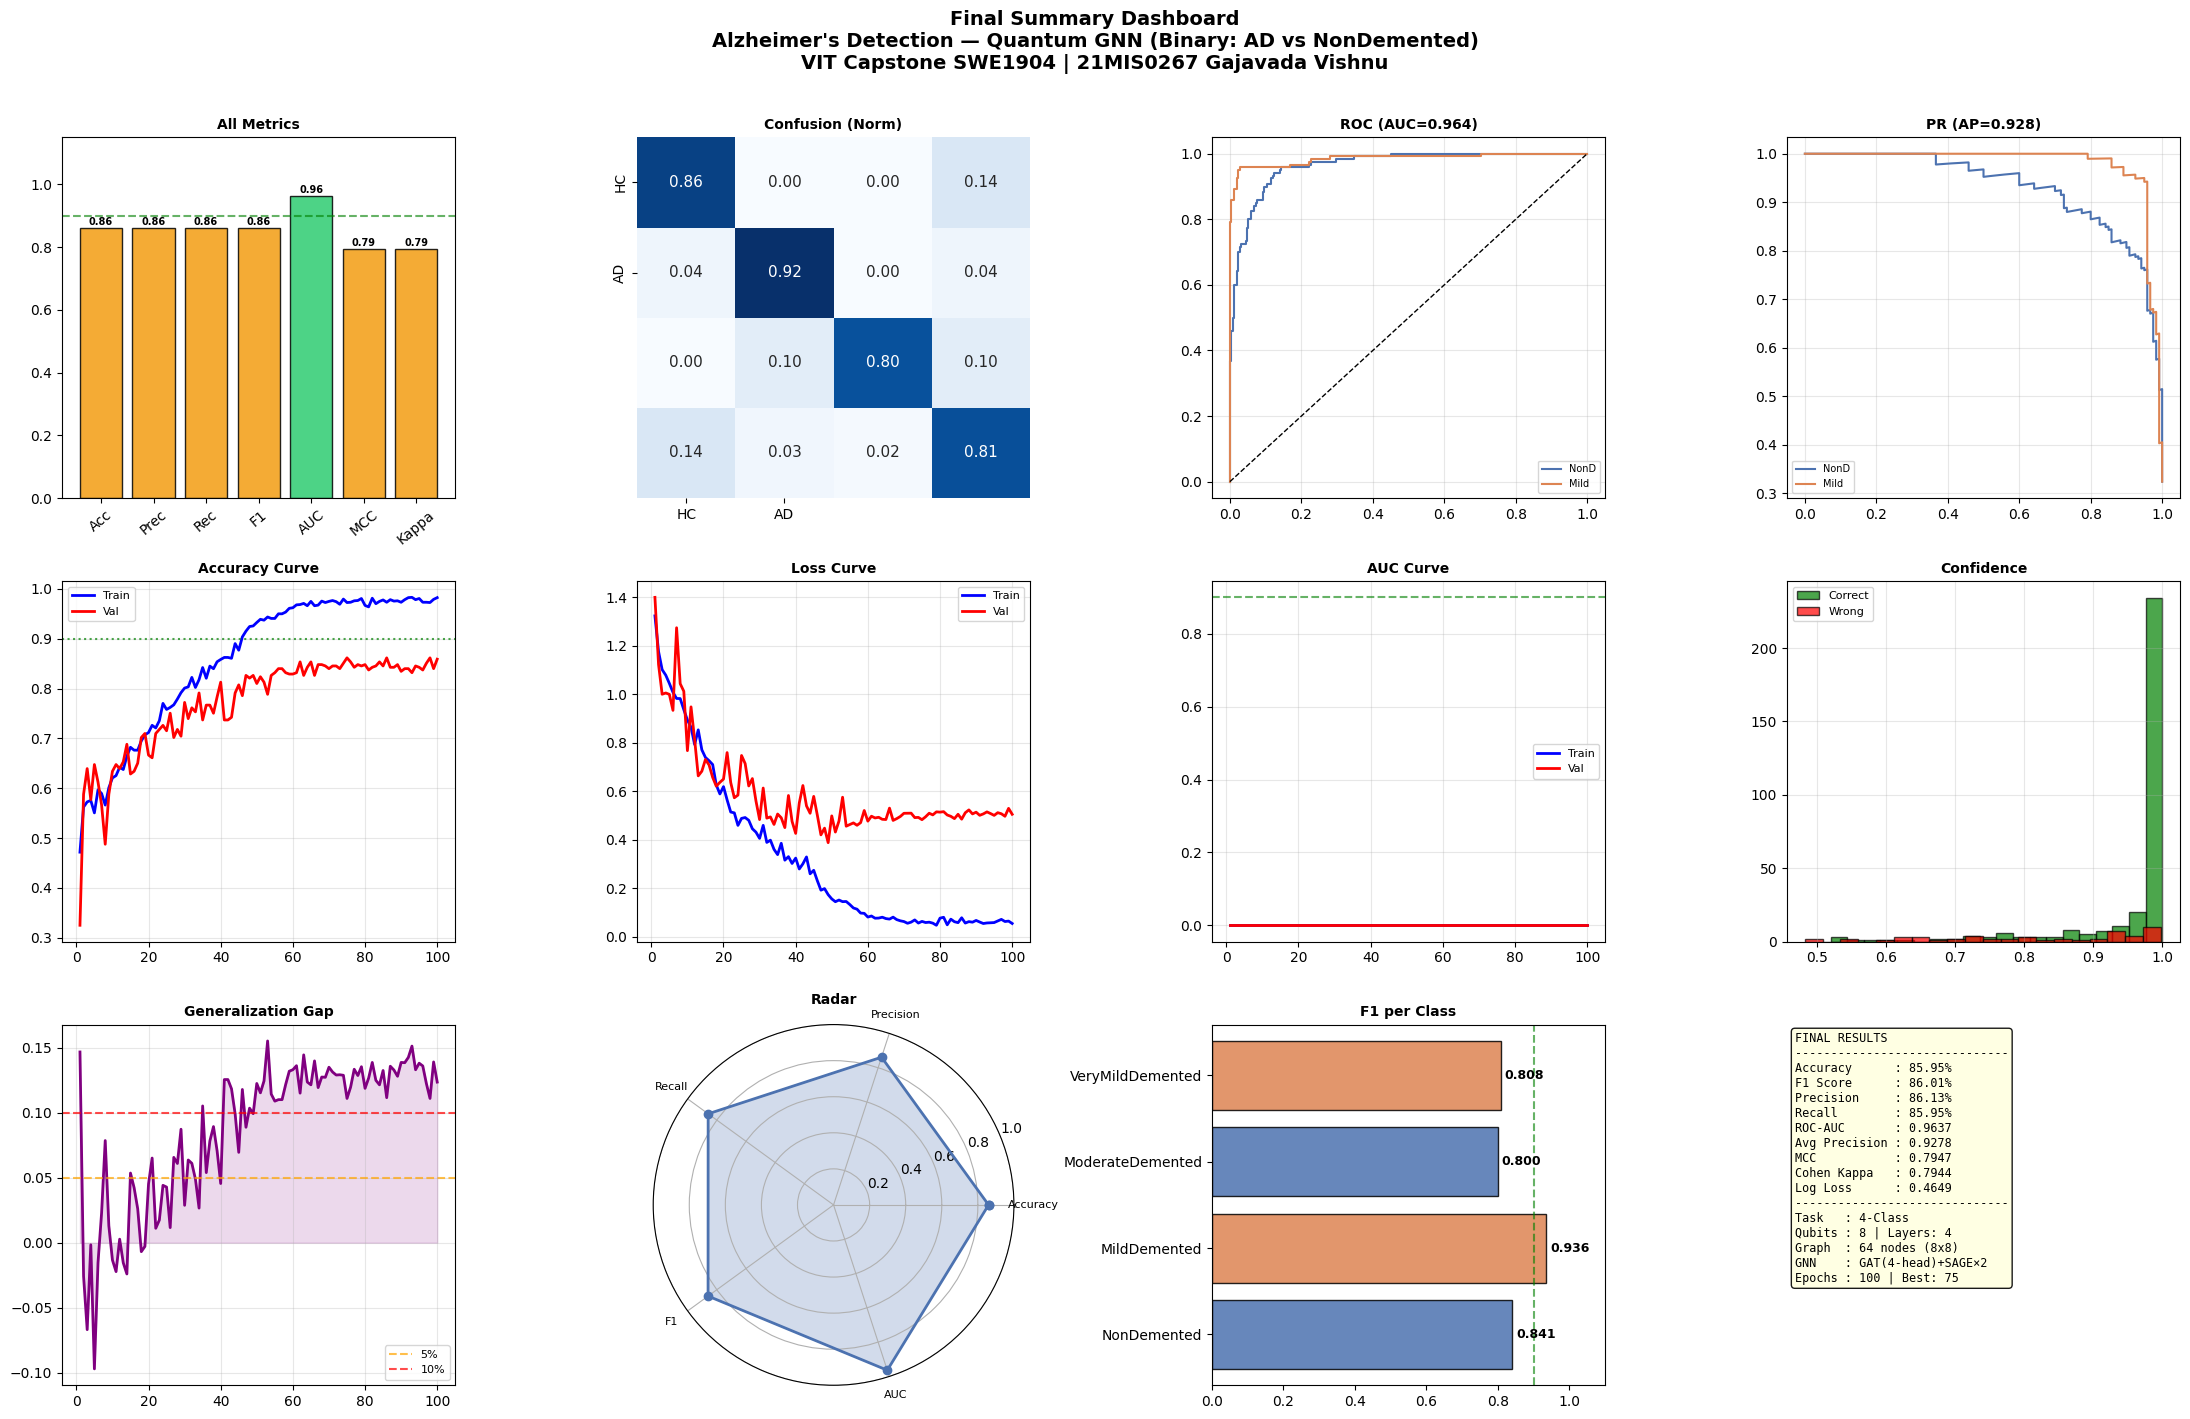


🏁 FINAL: Acc=85.95% | F1=86.01% | AUC=96.37%
 Saved: final_dashboard.png


In [ ]:
# CELL 23 — Final Summary Dashboard
fig = plt.figure(figsize=(22, 14))
fig.suptitle(
    "Final Summary Dashboard\n"
    "Alzheimer's Detection — Quantum GNN (Binary: AD vs NonDemented)\n"
    "VIT Capstone SWE1904 | 21MIS0267 Gajavada Vishnu",
    fontsize=14, fontweight='bold', y=1.01
)

# 1. Metrics bar
ax1 = fig.add_subplot(3, 4, 1)
mv  = [acc, prec, rec, f1, auc_s, mcc, kappa]
mn  = ['Acc','Prec','Rec','F1','AUC','MCC','Kappa']
mc  = ['#2ecc71' if v>=0.90 else '#e74c3c' if v<0.70 else '#f39c12' for v in mv]
bars = ax1.bar(mn, mv, color=mc, alpha=0.85, edgecolor='black')
ax1.axhline(0.90, color='green', ls='--', alpha=0.6)
ax1.set_ylim(0,1.15); ax1.set_title('All Metrics', fontsize=10, fontweight='bold')
for bar,v in zip(bars,mv):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}',
             ha='center', fontsize=7, fontweight='bold')
ax1.tick_params(axis='x', rotation=40)

# 2. Confusion
ax2 = fig.add_subplot(3, 4, 2)
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['HC','AD'], yticklabels=['HC','AD'],
            ax=ax2, cbar=False, annot_kws={'size':11})
ax2.set_title('Confusion (Norm)', fontsize=10, fontweight='bold')
ax2.tick_params(axis='x', rotation=0)

# 3. ROC
ax3 = fig.add_subplot(3, 4, 3)
for i,(cn,col) in enumerate(zip(CLASS_NAMES,COLORS)):
    fpr_i,tpr_i,_=roc_curve(test_labels_bin[:,i],test_probs_full[:,i])
    ax3.plot(fpr_i,tpr_i,color=col,lw=1.5,label=f'{cn[:4]}')
ax3.plot([0,1],[0,1],'k--',lw=1)
ax3.set_title(f'ROC (AUC={auc_s:.3f})', fontsize=10, fontweight='bold')
ax3.legend(fontsize=7); ax3.grid(True, alpha=0.3)

# 4. PR Curve
ax4 = fig.add_subplot(3, 4, 4)
for i,(cn,col) in enumerate(zip(CLASS_NAMES,COLORS)):
    p_i,r_i,_=precision_recall_curve(test_labels_bin[:,i],test_probs_full[:,i])
    ax4.plot(r_i,p_i,color=col,lw=1.5,label=f'{cn[:4]}')
ax4.set_title(f'PR (AP={ap:.3f})', fontsize=10, fontweight='bold')
ax4.legend(fontsize=7); ax4.grid(True, alpha=0.3)

# 5. Accuracy
ax5 = fig.add_subplot(3, 4, 5)
ax5.plot(ep, history['train_acc'], 'b-', lw=2, label='Train')
ax5.plot(ep, history['val_acc'],   'r-', lw=2, label='Val')
ax5.axhline(0.90, color='green', ls=':', alpha=0.7)
ax5.set_title('Accuracy Curve', fontsize=10, fontweight='bold')
ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3)

# 6. Loss
ax6 = fig.add_subplot(3, 4, 6)
ax6.plot(ep, history['train_loss'], 'b-', lw=2, label='Train')
ax6.plot(ep, history['val_loss'],   'r-', lw=2, label='Val')
ax6.set_title('Loss Curve', fontsize=10, fontweight='bold')
ax6.legend(fontsize=8); ax6.grid(True, alpha=0.3)

# 7. AUC curve
ax7 = fig.add_subplot(3, 4, 7)
ax7.plot(ep, history['train_auc'], 'b-', lw=2, label='Train')
ax7.plot(ep, history['val_auc'],   'r-', lw=2, label='Val')
ax7.axhline(0.90, color='green', ls='--', alpha=0.6)
ax7.set_title('AUC Curve', fontsize=10, fontweight='bold')
ax7.legend(fontsize=8); ax7.grid(True, alpha=0.3)

# 8. Confidence
ax8 = fig.add_subplot(3, 4, 8)
ax8.hist(max_probs[correct].tolist(),  bins=20, alpha=0.7,
         color='green', label='Correct', edgecolor='black')
ax8.hist(max_probs[~correct].tolist(), bins=20, alpha=0.7,
         color='red',   label='Wrong',   edgecolor='black')
ax8.set_title('Confidence', fontsize=10, fontweight='bold')
ax8.legend(fontsize=8); ax8.grid(True, alpha=0.3)

# 9. Generalization gap
ax9 = fig.add_subplot(3, 4, 9)
ax9.plot(ep, acc_gap, color='purple', lw=2)
ax9.fill_between(ep, acc_gap, 0, alpha=0.15, color='purple')
ax9.axhline(0.05, color='orange', ls='--', alpha=0.7, label='5%')
ax9.axhline(0.10, color='red',    ls='--', alpha=0.7, label='10%')
ax9.set_title('Generalization Gap', fontsize=10, fontweight='bold')
ax9.legend(fontsize=8); ax9.grid(True, alpha=0.3)

# 10. Radar
ax10 = fig.add_subplot(3, 4, 10, projection='polar')
r_names  = ['Accuracy','Precision','Recall','F1','AUC']
r_vals   = [acc, prec, rec, f1, auc_s]
N2 = len(r_names)
a2 = [n/float(N2)*2*np.pi for n in range(N2)] + [0]
r_plot = r_vals + r_vals[:1]
ax10.plot(a2, r_plot, 'o-', lw=2, color='#4C72B0')
ax10.fill(a2, r_plot, alpha=0.25, color='#4C72B0')
ax10.set_xticks(a2[:-1]); ax10.set_xticklabels(r_names, fontsize=8)
ax10.set_ylim(0,1); ax10.set_title('Radar', fontsize=10, fontweight='bold', pad=15)

# 11. Per-class F1
ax11 = fig.add_subplot(3, 4, 11)
ax11.barh(CLASS_NAMES, f_pc, color=COLORS, alpha=0.85, edgecolor='black')
ax11.axvline(0.90, color='green', ls='--', alpha=0.6)
ax11.set_xlim(0,1.1); ax11.set_title('F1 per Class', fontsize=10, fontweight='bold')
for i,v in enumerate(f_pc):
    ax11.text(v+0.01, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=9)

# 12. Summary text
ax12 = fig.add_subplot(3, 4, 12); ax12.axis('off')
txt = (
    f'FINAL RESULTS\n{"-"*30}\n'
    f'Accuracy      : {acc*100:.2f}%\n'
    f'F1 Score      : {f1*100:.2f}%\n'
    f'Precision     : {prec*100:.2f}%\n'
    f'Recall        : {rec*100:.2f}%\n'
    f'ROC-AUC       : {auc_s:.4f}\n'
    f'Avg Precision : {ap:.4f}\n'
    f'MCC           : {mcc:.4f}\n'
    f'Cohen Kappa   : {kappa:.4f}\n'
    f'Log Loss      : {ll:.4f}\n'
    f'{"-"*30}\n'
    f'Task   : 4-Class\n'
    f'Qubits : {N_QUBITS} | Layers: {N_LAYERS}\n'
    f'Graph  : 64 nodes (8x8)\n'
    f'GNN    : GAT(4-head)+SAGE×2\n'
    f'Epochs : {ep[-1]} | Best: {best_epoch}'
)
ax12.text(0.02, 0.98, txt, transform=ax12.transAxes,
          fontsize=8.5, va='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig('final_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'\n🏁 FINAL: Acc={acc*100:.2f}% | F1={f1*100:.2f}% | AUC={auc_s*100:.2f}%')
print(' Saved: final_dashboard.png')

In [ ]:
# CELL 24 — Save Model
save_path = '/content/drive/MyDrive/Efficient1/quantum_gat_sage_final.pth'
torch.save({
    'model_state_dict' : model.state_dict(),
    'test_accuracy'    : acc,
    'test_f1'          : f1,
    'test_auc'         : auc_s,
    'test_mcc'         : mcc,
    'test_kappa'       : kappa,
    'test_log_loss'    : ll,
    'class_names'      : CLASS_NAMES,
    'history'          : history,
    'best_epoch'       : best_epoch,
    'config': {
        'task'         : '4-class classification',
        'n_qubits'     : N_QUBITS,
        'n_layers'     : N_LAYERS,
        'hidden'       : HIDDEN,
        'image_grid'   : IMAGE_GRID,
        'node_features': 8,
        'architecture' : 'QFE(PennyLane) -> GATConv(4-head) -> SAGEConv x2 -> MLP'
    }
}, save_path)

print(f' Model saved to {save_path}')
print(f'\n{"="*50}')
print(f'  FINAL SUMMARY')
print(f'{"="*50}')
print(f'  Accuracy   : {acc*100:.2f}%')
print(f'  F1 Score   : {f1*100:.2f}%')
print(f'  ROC-AUC    : {auc_s*100:.2f}%')
print(f'  MCC        : {mcc:.4f}')
print(f'  Kappa      : {kappa:.4f}')
print(f'  Log Loss   : {ll:.4f}')
print(f'{"="*50}')

 Model saved to /content/drive/MyDrive/Efficient1/quantum_gat_sage_final.pth

  FINAL SUMMARY
  Accuracy   : 85.95%
  F1 Score   : 86.01%
  ROC-AUC    : 96.37%
  MCC        : 0.7947
  Kappa      : 0.7944
  Log Loss   : 0.4649
